# Tabular Q-Learning vs Deep Q-Network on CartPole-v1

**Course:** Artificial Intelligence — Project 3
**Environment:** CartPole-v1
**Research Question:** How does classical tabular Q-Learning compare to
Deep Q-Network (DQN) on a simple control task?

## Motivation
Tabular Q-Learning (Watkins, 1992) is one of the foundational algorithms
in reinforcement learning, directly derived from the Bellman equation
(AI Lecture Slides 14-15). However, it requires discretizing continuous
state spaces, which introduces approximation errors. Deep Q-Networks
(Mnih et al., 2015) replace the Q-table with a neural network, allowing
the agent to handle continuous states naturally. This experiment directly
compares these two approaches on CartPole-v1, where the state space is
small enough for tabular methods to work reasonably well, making it an
ideal benchmark for comparison.

## Experiments Overview
| # | Experiment | Variable | Values |
|---|-----------|----------|--------|
| 1 | Algorithm Comparison | algorithm | Q-Table, DQN |
| 2 | Discretization Bins (Q-Table) | n_bins | 6, 10, 20 |
| 3 | Learning Rate | learning_rate | 0.001, 0.01, 0.1 |
| 4 | Discount Factor γ | gamma | 0.90, 0.95, 0.99 |

## References
- Watkins, C.J.C.H. (1992). Q-learning. Machine Learning.
- Mnih et al. (2015). Human-level control through deep reinforcement learning.
- AI Lecture Slides 14-15: Q-Learning and Deep Q-Learning

## 1. Imports

In [1]:
import os
import time
import json
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import gymnasium as gym

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Gym    : {gym.__version__}")

Device : cpu
PyTorch: 2.11.0+cpu
Gym    : 1.2.3


## 2. Configuration

In [2]:
ENV_NAME = "CartPole-v1"
SEED     = 42

# CartPole specifics
# State: [cart position, cart velocity, pole angle, pole angular velocity]
# Actions: 0 (push left), 1 (push right)
# Solved: mean reward >= 475 over 100 episodes (max episode length = 500)

# Shared training settings
N_EPISODES     = 1000    # episodes for Q-Table
DQN_STEPS      = 100_000 # steps for DQN
EVAL_EVERY     = 50      # evaluate every N episodes/steps
EVAL_EPISODES  = 10      # episodes per evaluation

# Q-Table defaults
DEFAULT_N_BINS   = 10
DEFAULT_LR_TABLE = 0.1
DEFAULT_GAMMA    = 0.99
DEFAULT_EPS_START = 1.0
DEFAULT_EPS_END   = 0.01
DEFAULT_EPS_DECAY = 0.995

# DQN defaults
DEFAULT_LR_DQN    = 1e-3
DEFAULT_BATCH_SIZE = 64
DEFAULT_BUFFER_SIZE = 10_000
DEFAULT_TARGET_UPDATE = 100

RESULTS_DIR = "cartpole_results"
os.makedirs(RESULTS_DIR, exist_ok=True)

# CartPole state bounds for discretization
STATE_BOUNDS = [
    (-4.8, 4.8),      # cart position
    (-4.0, 4.0),      # cart velocity (clipped)
    (-0.418, 0.418),  # pole angle
    (-4.0, 4.0),      # pole angular velocity (clipped)
]

print(f"Environment  : {ENV_NAME}")
print(f"Solved at    : >= 475 mean reward")
print(f"Results dir  : {RESULTS_DIR}/")

Environment  : CartPole-v1
Solved at    : >= 475 mean reward
Results dir  : cartpole_results/


## 3. Tabular Q-Learning Implementation
Classical Q-Learning with state discretization.
Connected directly to AI Lecture Slides 14-15.
The continuous state space is divided into discrete bins,
and a Q-table stores one value per (state, action) pair.

In [3]:
class QTable:
    """
    Tabular Q-Learning agent for CartPole-v1.
    Uses state discretization to handle the continuous state space.

    The Q-table has shape (n_bins^4, n_actions) where n_bins is the
    number of discrete bins per state dimension.

    Reference: Watkins (1992); AI Lecture Slide 14-15.
    """
    def __init__(self, n_bins=DEFAULT_N_BINS,
                 lr=DEFAULT_LR_TABLE,
                 gamma=DEFAULT_GAMMA,
                 eps_start=DEFAULT_EPS_START,
                 eps_end=DEFAULT_EPS_END,
                 eps_decay=DEFAULT_EPS_DECAY):

        self.n_bins   = n_bins
        self.lr       = lr
        self.gamma    = gamma
        self.eps      = eps_start
        self.eps_end  = eps_end
        self.eps_decay = eps_decay
        self.n_actions = 2

        # Initialize Q-table with zeros
        # Shape: (n_bins, n_bins, n_bins, n_bins, n_actions)
        self.q_table = np.zeros([n_bins] * 4 + [self.n_actions])

        # Create bin edges for each state dimension
        self.bins = [
            np.linspace(low, high, n_bins + 1)[1:-1]
            for (low, high) in STATE_BOUNDS
        ]

    def discretize(self, state):
        """Convert continuous state to discrete bin indices."""
        return tuple(
            np.digitize(s, b)
            for s, b in zip(state, self.bins)
        )

    def select_action(self, state, deterministic=False):
        """ε-greedy action selection."""
        if not deterministic and np.random.random() < self.eps:
            return np.random.randint(self.n_actions)
        idx = self.discretize(state)
        return int(np.argmax(self.q_table[idx]))

    def update(self, state, action, reward, next_state, done):
        """
        Q-Learning update rule (Bellman equation):
        Q(s,a) ← Q(s,a) + α [r + γ max_a' Q(s',a') - Q(s,a)]
        Source: AI Lecture Slide 15.
        """
        idx      = self.discretize(state)
        idx_next = self.discretize(next_state)

        q_current = self.q_table[idx][action]
        q_next    = 0 if done else np.max(self.q_table[idx_next])
        td_target = reward + self.gamma * q_next
        td_error  = td_target - q_current

        self.q_table[idx][action] += self.lr * td_error

    def decay_epsilon(self):
        """Decay exploration rate after each episode."""
        self.eps = max(self.eps_end, self.eps * self.eps_decay)


print("✓ QTable defined.")

✓ QTable defined.


## 4. DQN Implementation
Deep Q-Network with experience replay and target network.
Connected to AI Lecture Slides 22-25.

In [4]:
class DQNNetwork(nn.Module):
    """
    Simple MLP Q-Network for CartPole.
    Input : state (4 dimensions)
    Output: Q-values for each action (2 actions)
    """
    def __init__(self, state_dim=4, n_actions=2, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x):
        return self.net(x)


class ReplayBuffer:
    """Experience replay buffer. Source: AI Lecture Slide 24."""
    def __init__(self, capacity=DEFAULT_BUFFER_SIZE):
        self.buffer = deque(maxlen=capacity)

    def add(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        idx  = np.random.choice(len(self.buffer), batch_size, replace=False)
        batch = [self.buffer[i] for i in idx]
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            torch.FloatTensor(np.array(states)).to(DEVICE),
            torch.LongTensor(actions).to(DEVICE),
            torch.FloatTensor(rewards).to(DEVICE),
            torch.FloatTensor(np.array(next_states)).to(DEVICE),
            torch.FloatTensor(dones).to(DEVICE),
        )

    def __len__(self):
        return len(self.buffer)


class DQNAgent:
    """
    Deep Q-Network agent for CartPole.
    Uses experience replay and target network for stable training.
    Reference: Mnih et al. (2015); AI Lecture Slides 22-25.
    """
    def __init__(self, lr=DEFAULT_LR_DQN,
                 gamma=DEFAULT_GAMMA,
                 batch_size=DEFAULT_BATCH_SIZE,
                 buffer_size=DEFAULT_BUFFER_SIZE,
                 target_update=DEFAULT_TARGET_UPDATE,
                 eps_start=DEFAULT_EPS_START,
                 eps_end=DEFAULT_EPS_END,
                 eps_decay=DEFAULT_EPS_DECAY):

        self.gamma        = gamma
        self.batch_size   = batch_size
        self.target_update = target_update
        self.eps          = eps_start
        self.eps_end      = eps_end
        self.eps_decay    = eps_decay
        self.steps        = 0

        self.online_net = DQNNetwork().to(DEVICE)
        self.target_net = DQNNetwork().to(DEVICE)
        self.target_net.load_state_dict(self.online_net.state_dict())
        self.target_net.eval()

        self.optimizer = torch.optim.Adam(self.online_net.parameters(), lr=lr)
        self.buffer    = ReplayBuffer(buffer_size)

    def select_action(self, state, deterministic=False):
        if not deterministic and np.random.random() < self.eps:
            return np.random.randint(2)
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(DEVICE)
            return int(self.online_net(state_t).argmax().item())

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return
        states, actions, rewards, next_states, dones = \
            self.buffer.sample(self.batch_size)

        # Current Q values
        q_current = self.online_net(states).gather(1, actions.unsqueeze(1))

        # Target Q values (Bellman equation)
        with torch.no_grad():
            q_next   = self.target_net(next_states).max(1)[0]
            q_target = rewards + self.gamma * q_next * (1 - dones)

        loss = F.smooth_l1_loss(q_current.squeeze(), q_target)
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        self.steps += 1
        # Decay epsilon
        self.eps = max(self.eps_end, self.eps * self.eps_decay)
        # Update target network
        if self.steps % self.target_update == 0:
            self.target_net.load_state_dict(self.online_net.state_dict())


print("✓ DQN defined.")

✓ DQN defined.


## 5. Training and Evaluation Functions

In [5]:
def evaluate_agent(env, agent, n_episodes=EVAL_EPISODES):
    """Run agent deterministically and return mean reward."""
    total = 0
    for _ in range(n_episodes):
        state, _ = env.reset()
        done = False
        while not done:
            action = agent.select_action(state, deterministic=True)
            state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            total += reward
    return total / n_episodes


def train_qtable(exp_name,
                 n_bins=DEFAULT_N_BINS,
                 lr=DEFAULT_LR_TABLE,
                 gamma=DEFAULT_GAMMA,
                 n_episodes=N_EPISODES):
    """
    Train tabular Q-Learning agent on CartPole.
    Caches results to disk.
    """
    path = os.path.join(RESULTS_DIR, f"{exp_name}.json")
    if os.path.exists(path):
        print(f"[{exp_name}] ✓ Loaded cached results.")
        with open(path) as f:
            return json.load(f)

    print(f"\n{'='*50}")
    print(f" Q-Table | {exp_name}")
    print(f" bins={n_bins}  lr={lr}  γ={gamma}  episodes={n_episodes}")
    print(f"{'='*50}")

    env      = gym.make(ENV_NAME)
    eval_env = gym.make(ENV_NAME)
    agent    = QTable(n_bins=n_bins, lr=lr, gamma=gamma)

    eval_episodes, eval_rewards = [], []
    episode_rewards = []
    t0 = time.time()

    for ep in range(n_episodes):
        state, _ = env.reset(seed=SEED + ep)
        done = False
        ep_reward = 0

        while not done:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.update(state, action, reward, next_state, done)
            state = next_state
            ep_reward += reward

        agent.decay_epsilon()
        episode_rewards.append(ep_reward)

        if (ep + 1) % EVAL_EVERY == 0:
            score = evaluate_agent(eval_env, agent)
            eval_episodes.append(ep + 1)
            eval_rewards.append(score)
            print(f"  Episode {ep+1:4d}  eval reward: {score:.1f}"
                  f"  ε: {agent.eps:.3f}")

    elapsed = time.time() - t0
    env.close()
    eval_env.close()

    result = {
        "exp_name"  : exp_name,
        "algorithm" : "Q-Table",
        "config"    : {"n_bins": n_bins, "lr": lr, "gamma": gamma,
                       "n_episodes": n_episodes},
        "metrics"   : {
            "best_reward"      : float(max(eval_rewards)) if eval_rewards else 0,
            "final_reward"     : float(np.mean(eval_rewards[-5:])) if len(eval_rewards) >= 5 else 0,
            "training_time_min": round(elapsed / 60, 2),
            "solved"           : any(r >= 475 for r in eval_rewards),
            "steps_to_solve"   : next((eval_episodes[i] for i, r
                                       in enumerate(eval_rewards) if r >= 475), None),
        },
        "history"   : {"episodes": eval_episodes, "rewards": eval_rewards,
                       "raw_rewards": episode_rewards},
    }
    with open(path, "w") as f:
        json.dump(result, f, indent=2)
    solved_str = f"at ep {result['metrics']['steps_to_solve']}" \
                 if result['metrics']['solved'] else "not solved"
    print(f"\n[{exp_name}] ✓  Best: {result['metrics']['best_reward']:.1f}"
          f"  Solved: {solved_str}  Time: {elapsed/60:.1f} min")
    return result


def train_dqn(exp_name,
              lr=DEFAULT_LR_DQN,
              gamma=DEFAULT_GAMMA,
              total_steps=DQN_STEPS):
    """
    Train DQN agent on CartPole.
    Caches results to disk.
    """
    path = os.path.join(RESULTS_DIR, f"{exp_name}.json")
    if os.path.exists(path):
        print(f"[{exp_name}] ✓ Loaded cached results.")
        with open(path) as f:
            return json.load(f)

    print(f"\n{'='*50}")
    print(f" DQN | {exp_name}")
    print(f" lr={lr}  γ={gamma}  steps={total_steps:,}")
    print(f"{'='*50}")

    env      = gym.make(ENV_NAME)
    eval_env = gym.make(ENV_NAME)
    agent    = DQNAgent(lr=lr, gamma=gamma)

    eval_steps, eval_rewards = [], []
    t0    = time.time()
    total = 0
    ep    = 0

    while total < total_steps:
        state, _ = env.reset(seed=SEED + ep)
        done = False
        ep  += 1

        while not done and total < total_steps:
            action = agent.select_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.buffer.add(state, action, reward, next_state, float(done))
            agent.train_step()
            state = next_state
            total += 1

        if ep % EVAL_EVERY == 0:
            score = evaluate_agent(eval_env, agent)
            eval_steps.append(total)
            eval_rewards.append(score)
            print(f"  Step {total//1000:3d}k  ep {ep:4d}  "
                  f"eval reward: {score:.1f}  ε: {agent.eps:.3f}")

    elapsed = time.time() - t0
    env.close()
    eval_env.close()

    result = {
        "exp_name"  : exp_name,
        "algorithm" : "DQN",
        "config"    : {"lr": lr, "gamma": gamma, "total_steps": total_steps},
        "metrics"   : {
            "best_reward"      : float(max(eval_rewards)) if eval_rewards else 0,
            "final_reward"     : float(np.mean(eval_rewards[-5:])) if len(eval_rewards) >= 5 else 0,
            "training_time_min": round(elapsed / 60, 2),
            "solved"           : any(r >= 475 for r in eval_rewards),
            "steps_to_solve"   : next((eval_steps[i] for i, r
                                       in enumerate(eval_rewards) if r >= 475), None),
        },
        "history"   : {"episodes": eval_steps, "rewards": eval_rewards},
    }
    with open(path, "w") as f:
        json.dump(result, f, indent=2)
    solved_str = (f"at step {result['metrics']['steps_to_solve']:,}"
                  if result['metrics']['solved'] else "not solved")
    print(f"\n[{exp_name}] ✓  Best: {result['metrics']['best_reward']:.1f}"
          f"  Solved: {solved_str}  Time: {elapsed/60:.1f} min")
    return result


print("✓ Training functions defined.")

✓ Training functions defined.


## 6. Plotting Functions

In [6]:
def smooth(values, window=10):
    return pd.Series(values).rolling(window=window, min_periods=1).mean().values


def plot_comparison(results_list, title, x_label="Episode / Step",
                    solved_line=475, colors=None):
    """Two-panel: learning curves + final reward bar chart."""
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, res in enumerate(results_list):
        steps   = np.array(res["history"]["episodes"])
        rewards = np.array(res["history"]["rewards"])
        label   = f"{res['algorithm']} ({res['exp_name'].replace('_', ' ')})"
        if len(rewards) == 0:
            continue
        w = max(1, len(rewards) // 8)
        axes[0].plot(steps, rewards, alpha=0.25, color=colors[i], linewidth=0.8)
        axes[0].plot(steps, smooth(rewards, w), label=label,
                     color=colors[i], linewidth=2)

    axes[0].axhline(solved_line, color="green", linestyle="--",
                    alpha=0.7, label=f"Solved ({solved_line})")
    axes[0].axhline(500, color="gray", linestyle=":", alpha=0.4, label="Max (500)")
    axes[0].set_xlabel(x_label, fontsize=11)
    axes[0].set_ylabel("Mean Episode Reward", fontsize=11)
    axes[0].set_title("Learning Curves (smoothed)", fontsize=11)
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    labels = [f"{r['algorithm']}\n{r['exp_name'].replace('_', ' ')}"
              for r in results_list]
    finals = [r["metrics"]["final_reward"] for r in results_list]
    bars   = axes[1].bar(labels, finals, color=colors[:len(labels)],
                         alpha=0.85, edgecolor="white", width=0.5)
    axes[1].axhline(solved_line, color="green", linestyle="--",
                    alpha=0.7, label="Solved")
    axes[1].set_ylabel("Final Mean Reward (last 5 evals)", fontsize=11)
    axes[1].set_title("Final Performance", fontsize=11)
    axes[1].set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    axes[1].grid(True, alpha=0.3, axis="y")
    axes[1].legend(fontsize=9)
    for bar, val in zip(bars, finals):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 3,
                     f"{val:.0f}", ha="center", fontsize=10, fontweight="bold")

    plt.tight_layout()
    save = title.replace(" ", "_").replace(":", "").replace("/", "-")
    plt.savefig(os.path.join(RESULTS_DIR, f"{save}.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def plot_raw_rewards(results_list, title, colors=None, window=20):
    """Plot raw episode rewards with smoothing for all variants."""
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    fig, ax = plt.subplots(figsize=(11, 5))
    fig.suptitle(title, fontsize=13, fontweight="bold")

    for i, res in enumerate(results_list):
        raw = res["history"].get("raw_rewards", res["history"]["rewards"])
        episodes = np.arange(len(raw))
        label = f"{res['algorithm']} ({res['exp_name'].replace('_', ' ')})"
        ax.plot(episodes, raw, alpha=0.15, color=colors[i], linewidth=0.5)
        ax.plot(episodes, smooth(raw, window), label=label,
                color=colors[i], linewidth=2)

    ax.axhline(475, color="green", linestyle="--", alpha=0.7, label="Solved (475)")
    ax.axhline(500, color="gray",  linestyle=":",  alpha=0.4, label="Max (500)")
    ax.set_xlabel("Episode", fontsize=11)
    ax.set_ylabel("Episode Reward", fontsize=11)
    ax.set_title("Raw Episode Rewards (smoothed)", fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    save = title.replace(" ", "_").replace(":", "")
    plt.savefig(os.path.join(RESULTS_DIR, f"{save}_raw.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def plot_convergence(results_list, title, colors=None):
    """Bar chart showing steps/episodes needed to first solve the task."""
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, len(results_list)))

    labels = [f"{r['algorithm']}\n{r['exp_name'].replace('_', ' ')}"
              for r in results_list]
    speeds = []
    for res in results_list:
        s = res["metrics"].get("steps_to_solve")
        speeds.append(s if s else (N_EPISODES if res["algorithm"] == "Q-Table"
                                   else DQN_STEPS))

    fig, ax = plt.subplots(figsize=(9, 4))
    bars = ax.bar(labels, speeds, color=colors[:len(labels)],
                  alpha=0.85, edgecolor="white")
    ax.set_ylabel("Steps / Episodes to First Solve", fontsize=11)
    ax.set_title(f"{title} — Convergence Speed", fontsize=12, fontweight="bold")
    ax.set_xticklabels(labels, rotation=15, ha="right")
    ax.grid(True, alpha=0.3, axis="y")
    for bar, res, val in zip(bars, results_list, speeds):
        solved = res["metrics"]["solved"]
        label  = (f"{val}" if solved else "not solved")
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(speeds) * 0.01,
                label, ha="center", fontsize=9,
                color="green" if solved else "red", fontweight="bold")
    plt.tight_layout()
    save = title.replace(" ", "_")
    plt.savefig(os.path.join(RESULTS_DIR, f"{save}_convergence.png"),
                dpi=150, bbox_inches="tight")
    plt.show()


def make_table(results_list, key_col, key_label):
    """Build summary DataFrame for the report."""
    rows = []
    for r in results_list:
        rows.append({
            "Experiment"       : r["exp_name"].replace("_", " "),
            "Algorithm"        : r["algorithm"],
            key_label          : r["config"].get(key_col, "—"),
            "Best Reward"      : f"{r['metrics']['best_reward']:.1f}",
            "Final Reward"     : f"{r['metrics']['final_reward']:.1f}",
            "Solved"           : "Yes" if r["metrics"]["solved"] else "No",
            "Steps to Solve"   : (str(r["metrics"]["steps_to_solve"])
                                  if r["metrics"]["steps_to_solve"] else "—"),
            "Train Time (min)" : r["metrics"]["training_time_min"],
        })
    return pd.DataFrame(rows)


print("✓ Plotting functions defined.")

# ─────────────────────────────────────────────────────────────

✓ Plotting functions defined.


---
## Experiment 1 — Q-Table vs DQN

**Research question:** How does classical tabular Q-Learning compare to
Deep Q-Network on CartPole-v1?

This experiment provides the most direct comparison between the two
fundamental approaches to Q-Learning discussed in the AI lecture.
Tabular Q-Learning (Slide 14-15) discretizes the state space into bins
and stores one Q-value per (state, action) pair. DQN (Slide 22-23)
replaces the table with a neural network, allowing it to generalize
across similar states without explicit discretization.

**Hypothesis:** DQN will solve CartPole more reliably because it can
generalize across similar states, while Q-Table performance depends
heavily on the quality of the discretization.

In [7]:
exp1_qtable = train_qtable("exp1_qtable")
exp1_dqn    = train_dqn("exp1_dqn")

exp1_results = [exp1_qtable, exp1_dqn]
print("\nExperiment 1 complete.")


 Q-Table | exp1_qtable
 bins=10  lr=0.1  γ=0.99  episodes=1000
  Episode   50  eval reward: 32.5  ε: 0.778
  Episode  100  eval reward: 72.4  ε: 0.606
  Episode  150  eval reward: 60.0  ε: 0.471
  Episode  200  eval reward: 55.6  ε: 0.367
  Episode  250  eval reward: 49.7  ε: 0.286
  Episode  300  eval reward: 38.5  ε: 0.222
  Episode  350  eval reward: 61.9  ε: 0.173
  Episode  400  eval reward: 58.8  ε: 0.135
  Episode  450  eval reward: 47.6  ε: 0.105
  Episode  500  eval reward: 45.9  ε: 0.082
  Episode  550  eval reward: 158.5  ε: 0.063
  Episode  600  eval reward: 65.5  ε: 0.049
  Episode  650  eval reward: 147.7  ε: 0.038
  Episode  700  eval reward: 55.6  ε: 0.030
  Episode  750  eval reward: 53.1  ε: 0.023
  Episode  800  eval reward: 56.3  ε: 0.018
  Episode  850  eval reward: 84.0  ε: 0.014
  Episode  900  eval reward: 109.8  ε: 0.011
  Episode  950  eval reward: 166.6  ε: 0.010
  Episode 1000  eval reward: 166.9  ε: 0.010

[exp1_qtable] ✓  Best: 166.9  Solved: not solved  

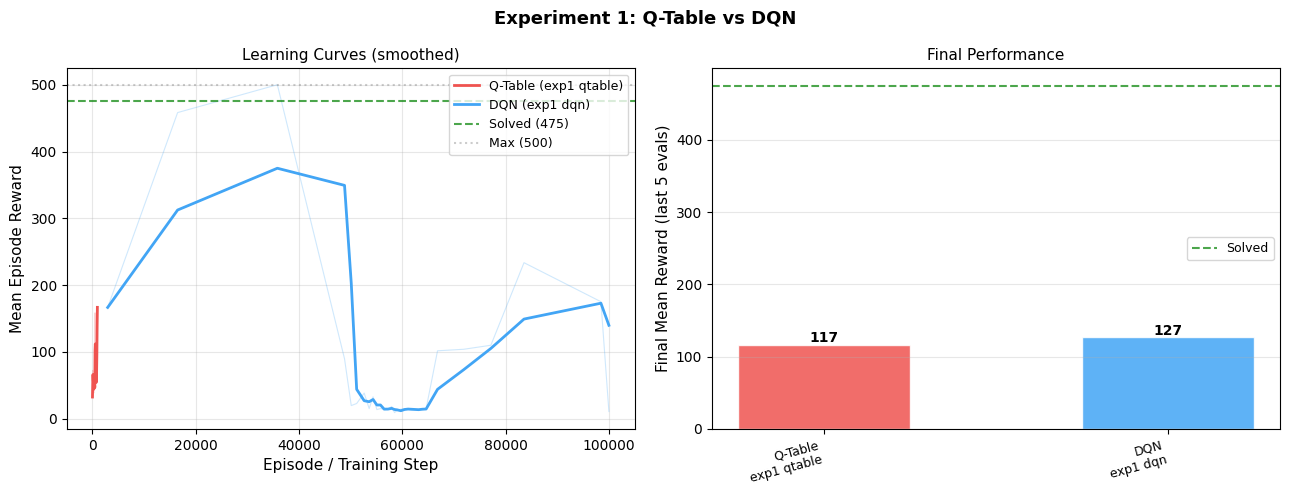

In [8]:
plot_comparison(
    exp1_results,
    title   = "Experiment 1: Q-Table vs DQN",
    x_label = "Episode / Training Step",
    colors  = ["#EF5350", "#42A5F5"],
)

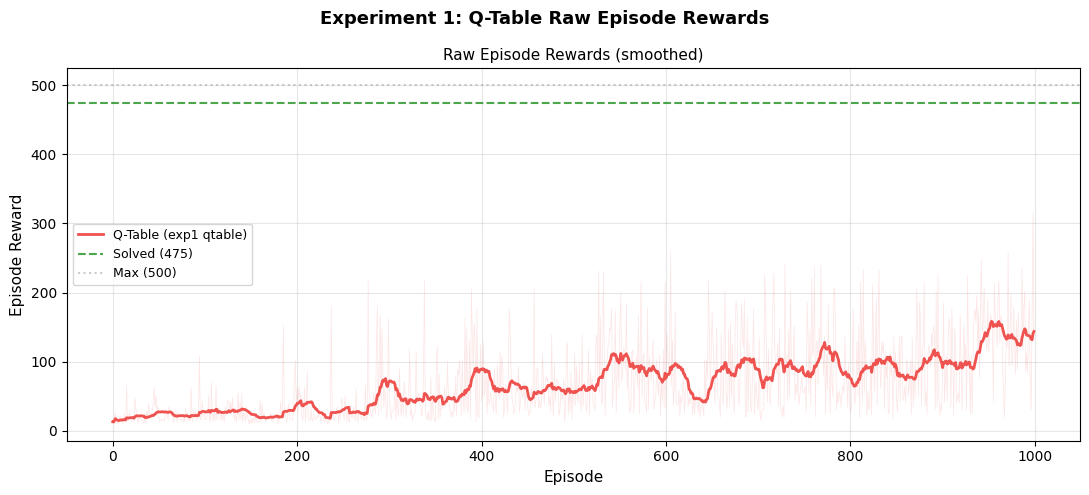

In [9]:
plot_raw_rewards(
    [exp1_qtable],
    title  = "Experiment 1: Q-Table Raw Episode Rewards",
    colors = ["#EF5350"],
)

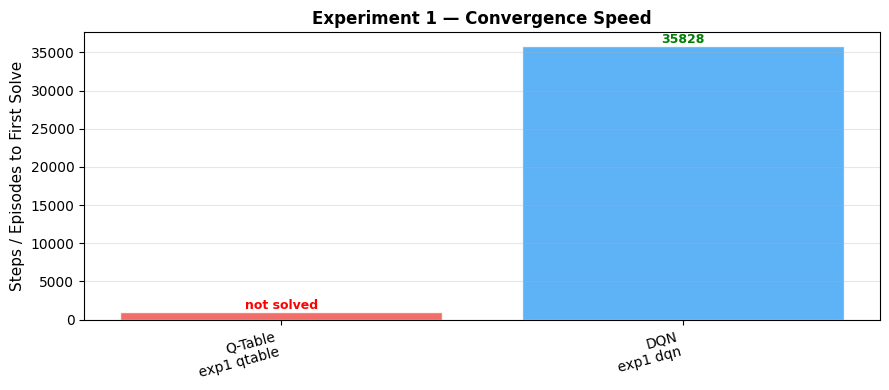

In [10]:
plot_convergence(
    exp1_results,
    title  = "Experiment 1",
    colors = ["#EF5350", "#42A5F5"],
)

In [11]:
df1 = make_table(exp1_results, key_col="n_bins", key_label="Bins / Steps")
print("\nExperiment 1 — Results Summary")
print(df1.to_string(index=False))
df1.to_csv(os.path.join(RESULTS_DIR, "exp1_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────


Experiment 1 — Results Summary
 Experiment Algorithm Bins / Steps Best Reward Final Reward Solved Steps to Solve  Train Time (min)
exp1 qtable   Q-Table           10       166.9        116.7     No              —              0.22
   exp1 dqn       DQN            —       500.0        126.7    Yes          35828             10.11


---
## Experiment 2 — Discretization Bins (Q-Table only)

**Research question:** How does the number of discretization bins affect
the performance of tabular Q-Learning?

This experiment is unique to the Q-Table approach — it has no equivalent
in DQN. More bins create a finer representation of the state space,
potentially capturing more information, but also increase the size of
the Q-table exponentially (n_bins^4 states) and make it harder to visit
all states enough times during training.

| Variant | Bins per dimension | Q-table size |
|---------|-------------------|--------------|
| Coarse  | 6                 | 6^4 = 1,296  |
| Medium  | 10                | 10^4 = 10,000 |
| Fine    | 20                | 20^4 = 160,000 |

In [12]:
exp2_configs = [
    ("exp2_bins_06", 6),
    ("exp2_bins_10", 10),
    ("exp2_bins_20", 20),
]

exp2_results = []
for name, n_bins in exp2_configs:
    res = train_qtable(name, n_bins=n_bins)
    exp2_results.append(res)

print("\nExperiment 2 complete.")


 Q-Table | exp2_bins_06
 bins=6  lr=0.1  γ=0.99  episodes=1000
  Episode   50  eval reward: 11.6  ε: 0.778
  Episode  100  eval reward: 35.0  ε: 0.606
  Episode  150  eval reward: 29.8  ε: 0.471
  Episode  200  eval reward: 41.7  ε: 0.367
  Episode  250  eval reward: 36.9  ε: 0.286
  Episode  300  eval reward: 58.9  ε: 0.222
  Episode  350  eval reward: 89.5  ε: 0.173
  Episode  400  eval reward: 82.4  ε: 0.135
  Episode  450  eval reward: 76.3  ε: 0.105
  Episode  500  eval reward: 59.6  ε: 0.082
  Episode  550  eval reward: 92.6  ε: 0.063
  Episode  600  eval reward: 75.2  ε: 0.049
  Episode  650  eval reward: 108.1  ε: 0.038
  Episode  700  eval reward: 113.7  ε: 0.030
  Episode  750  eval reward: 152.3  ε: 0.023
  Episode  800  eval reward: 202.5  ε: 0.018
  Episode  850  eval reward: 137.3  ε: 0.014
  Episode  900  eval reward: 181.8  ε: 0.011
  Episode  950  eval reward: 147.9  ε: 0.010
  Episode 1000  eval reward: 201.1  ε: 0.010

[exp2_bins_06] ✓  Best: 202.5  Solved: not solv

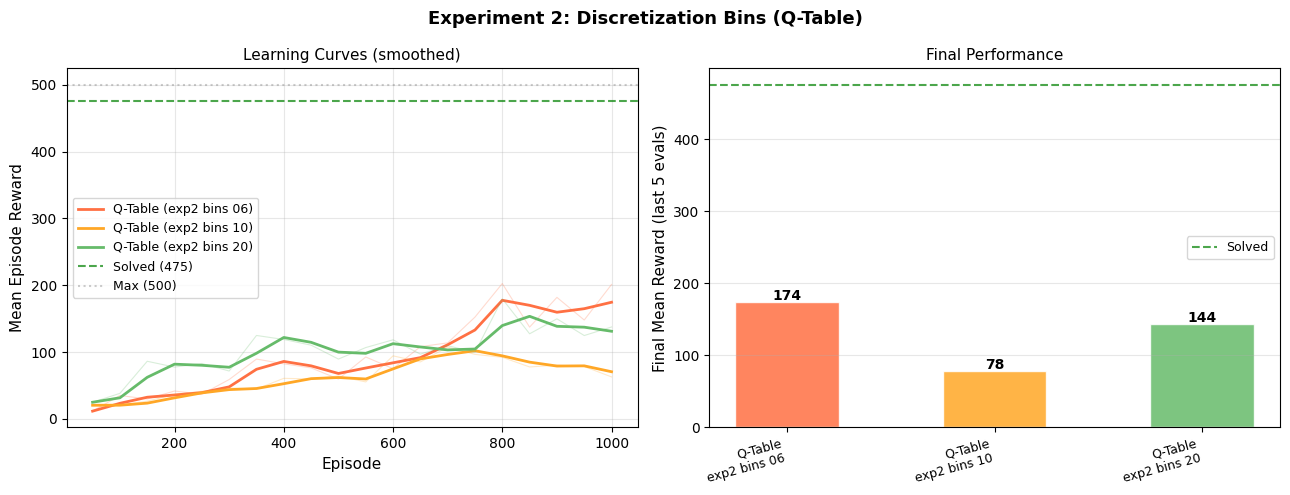

In [13]:
plot_comparison(
    exp2_results,
    title   = "Experiment 2: Discretization Bins (Q-Table)",
    x_label = "Episode",
    colors  = ["#FF7043", "#FFA726", "#66BB6A"],
)

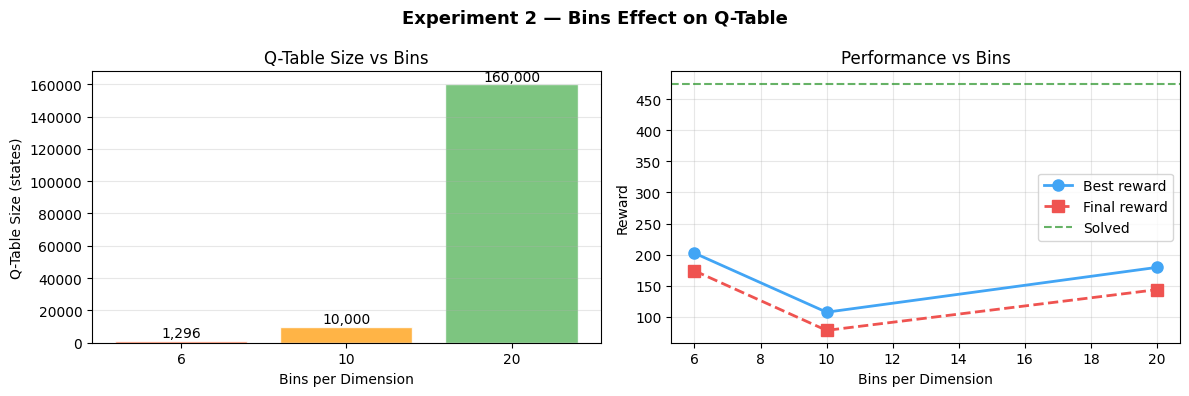

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 2 — Bins Effect on Q-Table", fontsize=13, fontweight="bold")

bins_list  = [6, 10, 20]
qtable_sizes = [b**4 for b in bins_list]
final_rews = [r["metrics"]["final_reward"] for r in exp2_results]
best_rews  = [r["metrics"]["best_reward"]  for r in exp2_results]
colors_e2  = ["#FF7043", "#FFA726", "#66BB6A"]

axes[0].bar([str(b) for b in bins_list], qtable_sizes,
            color=colors_e2, alpha=0.85, edgecolor="white")
axes[0].set_xlabel("Bins per Dimension")
axes[0].set_ylabel("Q-Table Size (states)")
axes[0].set_title("Q-Table Size vs Bins")
axes[0].grid(True, alpha=0.3, axis="y")
for i, (b, s) in enumerate(zip(bins_list, qtable_sizes)):
    axes[0].text(i, s + 2000, f"{s:,}", ha="center", fontsize=10)

axes[1].plot(bins_list, best_rews, "o-", color="#42A5F5",
             linewidth=2, markersize=8, label="Best reward")
axes[1].plot(bins_list, final_rews, "s--", color="#EF5350",
             linewidth=2, markersize=8, label="Final reward")
axes[1].axhline(475, color="green", linestyle="--", alpha=0.6, label="Solved")
axes[1].set_xlabel("Bins per Dimension")
axes[1].set_ylabel("Reward")
axes[1].set_title("Performance vs Bins")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp2_bins_effect.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [15]:
df2 = make_table(exp2_results, key_col="n_bins", key_label="Bins")
print("\nExperiment 2 — Results Summary")
print(df2.to_string(index=False))
df2.to_csv(os.path.join(RESULTS_DIR, "exp2_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────


Experiment 2 — Results Summary
  Experiment Algorithm  Bins Best Reward Final Reward Solved Steps to Solve  Train Time (min)
exp2 bins 06   Q-Table     6       202.5        174.1     No              —              0.42
exp2 bins 10   Q-Table    10       107.5         78.3     No              —              0.26
exp2 bins 20   Q-Table    20       179.6        143.8     No              —              0.38


---
## Experiment 3 — Learning Rate Comparison

**Research question:** How does the learning rate affect convergence
speed and stability for both Q-Table and DQN?

The learning rate α controls how much the agent updates its Q-values
after each experience. A high learning rate causes fast but potentially
unstable updates, while a low learning rate is more stable but slower
to converge. This is relevant for both algorithms but affects them
differently — in Q-Table, α directly scales the TD error update,
while in DQN it controls the neural network gradient step.

| Variant | Learning Rate | Expected behavior |
|---------|--------------|------------------|
| Low     | 0.001        | Slow but stable |
| Medium  | 0.01         | Balanced |
| High    | 0.1          | Fast but potentially unstable |

In [16]:
exp3_qtable_configs = [
    ("exp3_qtable_lr001", 0.001),
    ("exp3_qtable_lr010", 0.01),
    ("exp3_qtable_lr100", 0.1),
]

exp3_qtable_results = []
for name, lr in exp3_qtable_configs:
    res = train_qtable(name, lr=lr)
    exp3_qtable_results.append(res)


 Q-Table | exp3_qtable_lr001
 bins=10  lr=0.001  γ=0.99  episodes=1000
  Episode   50  eval reward: 26.1  ε: 0.778
  Episode  100  eval reward: 34.8  ε: 0.606
  Episode  150  eval reward: 59.3  ε: 0.471
  Episode  200  eval reward: 32.6  ε: 0.367
  Episode  250  eval reward: 35.4  ε: 0.286
  Episode  300  eval reward: 45.1  ε: 0.222
  Episode  350  eval reward: 47.1  ε: 0.173
  Episode  400  eval reward: 44.4  ε: 0.135
  Episode  450  eval reward: 47.1  ε: 0.105
  Episode  500  eval reward: 35.3  ε: 0.082
  Episode  550  eval reward: 61.2  ε: 0.063
  Episode  600  eval reward: 31.1  ε: 0.049
  Episode  650  eval reward: 46.0  ε: 0.038
  Episode  700  eval reward: 37.8  ε: 0.030
  Episode  750  eval reward: 48.7  ε: 0.023
  Episode  800  eval reward: 44.0  ε: 0.018
  Episode  850  eval reward: 46.4  ε: 0.014
  Episode  900  eval reward: 39.1  ε: 0.011
  Episode  950  eval reward: 50.8  ε: 0.010
  Episode 1000  eval reward: 28.0  ε: 0.010

[exp3_qtable_lr001] ✓  Best: 61.2  Solved: not 

In [18]:
exp3_dqn_configs = [
    ("exp3_dqn_lr0001", 0.0001),
    ("exp3_dqn_lr001",  0.001),
    ("exp3_dqn_lr01",   0.01),
]

exp3_dqn_results = []
for name, lr in exp3_dqn_configs:
    res = train_dqn(name, lr=lr)
    exp3_dqn_results.append(res)

print("\nExperiment 3 complete.")


 DQN | exp3_dqn_lr0001
 lr=0.0001  γ=0.99  steps=100,000
  Step   0k  ep   50  eval reward: 9.4  ε: 0.061
  Step   1k  ep  100  eval reward: 9.4  ε: 0.010
  Step   1k  ep  150  eval reward: 9.4  ε: 0.010
  Step   2k  ep  200  eval reward: 9.1  ε: 0.010
  Step   2k  ep  250  eval reward: 9.2  ε: 0.010
  Step   2k  ep  300  eval reward: 9.3  ε: 0.010
  Step   3k  ep  350  eval reward: 9.8  ε: 0.010
  Step   4k  ep  400  eval reward: 29.1  ε: 0.010
  Step   6k  ep  450  eval reward: 62.0  ε: 0.010
  Step  11k  ep  500  eval reward: 76.5  ε: 0.010
  Step  16k  ep  550  eval reward: 83.9  ε: 0.010
  Step  19k  ep  600  eval reward: 36.1  ε: 0.010
  Step  20k  ep  650  eval reward: 23.6  ε: 0.010
  Step  21k  ep  700  eval reward: 14.5  ε: 0.010
  Step  22k  ep  750  eval reward: 9.6  ε: 0.010
  Step  22k  ep  800  eval reward: 9.2  ε: 0.010
  Step  23k  ep  850  eval reward: 9.3  ε: 0.010
  Step  23k  ep  900  eval reward: 9.2  ε: 0.010
  Step  24k  ep  950  eval reward: 9.6  ε: 0.010
  St

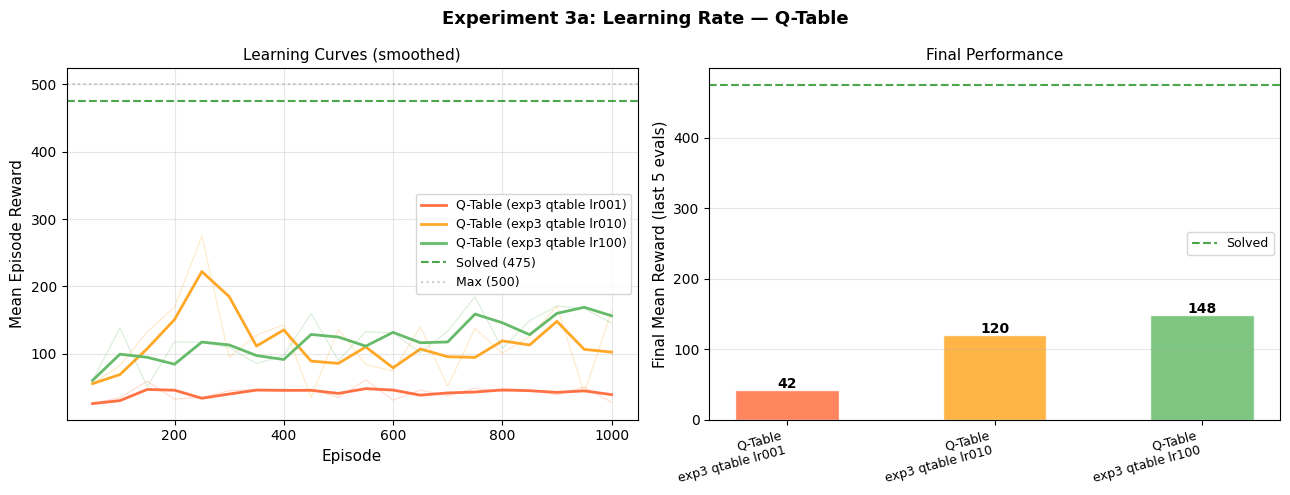

In [19]:
plot_comparison(
    exp3_qtable_results,
    title   = "Experiment 3a: Learning Rate — Q-Table",
    x_label = "Episode",
    colors  = ["#FF7043", "#FFA726", "#66BB6A"],
)

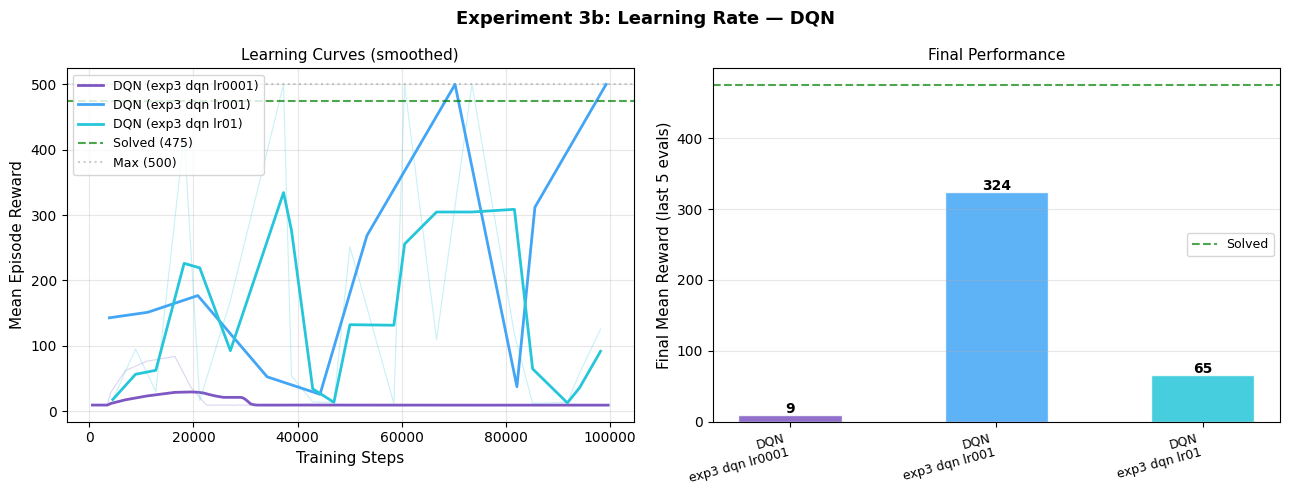

In [20]:
plot_comparison(
    exp3_dqn_results,
    title   = "Experiment 3b: Learning Rate — DQN",
    x_label = "Training Steps",
    colors  = ["#7E57C2", "#42A5F5", "#26C6DA"],
)

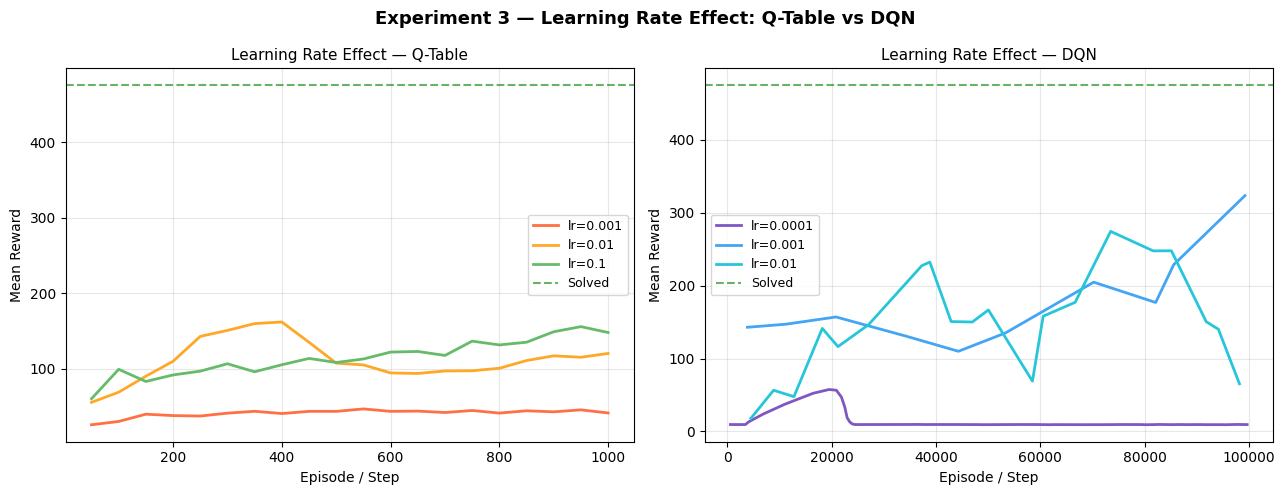

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Experiment 3 — Learning Rate Effect: Q-Table vs DQN",
             fontsize=13, fontweight="bold")

colors_qtable = ["#FF7043", "#FFA726", "#66BB6A"]
colors_dqn    = ["#7E57C2", "#42A5F5", "#26C6DA"]

for i, res in enumerate(exp3_qtable_results):
    rewards = np.array(res["history"]["rewards"])
    steps   = np.array(res["history"]["episodes"])
    lr_val  = res["config"]["lr"]
    axes[0].plot(steps, smooth(rewards, 5), label=f"lr={lr_val}",
                 color=colors_qtable[i], linewidth=2)

for i, res in enumerate(exp3_dqn_results):
    rewards = np.array(res["history"]["rewards"])
    steps   = np.array(res["history"]["episodes"])
    lr_val  = res["config"]["lr"]
    axes[1].plot(steps, smooth(rewards, 5), label=f"lr={lr_val}",
                 color=colors_dqn[i], linewidth=2)

for ax, title in zip(axes, ["Q-Table", "DQN"]):
    ax.axhline(475, color="green", linestyle="--", alpha=0.6, label="Solved")
    ax.set_title(f"Learning Rate Effect — {title}", fontsize=11)
    ax.set_xlabel("Episode / Step"); ax.set_ylabel("Mean Reward")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp3_lr_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [22]:
df3a = make_table(exp3_qtable_results, key_col="lr", key_label="Learning Rate")
df3b = make_table(exp3_dqn_results,    key_col="lr", key_label="Learning Rate")
print("\nExperiment 3a — Q-Table Learning Rate")
print(df3a[["Experiment", "Learning Rate", "Best Reward", "Solved", "Train Time (min)"]].to_string(index=False))
print("\nExperiment 3b — DQN Learning Rate")
print(df3b[["Experiment", "Learning Rate", "Best Reward", "Solved", "Train Time (min)"]].to_string(index=False))
df3a.to_csv(os.path.join(RESULTS_DIR, "exp3a_summary.csv"), index=False)
df3b.to_csv(os.path.join(RESULTS_DIR, "exp3b_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────


Experiment 3a — Q-Table Learning Rate
       Experiment  Learning Rate Best Reward Solved  Train Time (min)
exp3 qtable lr001          0.001        61.2     No              0.17
exp3 qtable lr010          0.010       274.7     No              0.40
exp3 qtable lr100          0.100       184.5     No              0.69

Experiment 3b — DQN Learning Rate
     Experiment  Learning Rate Best Reward Solved  Train Time (min)
exp3 dqn lr0001         0.0001        83.9     No             11.47
 exp3 dqn lr001         0.0010       500.0    Yes             10.72
  exp3 dqn lr01         0.0100       500.0    Yes             10.20


---
## Experiment 4 — Discount Factor γ

**Research question:** How does the discount factor affect learning
for both Q-Table and DQN on CartPole?

The discount factor γ controls how much the agent values future rewards
relative to immediate ones (AI Lecture Slide 7). For CartPole, where
the agent must balance the pole for as long as possible, a high γ
encourages the agent to plan ahead and maintain balance over many steps.
A low γ makes the agent short-sighted, potentially causing it to take
actions that keep the pole balanced momentarily but fail in the long run.

| Variant | γ | Planning horizon |
|---------|---|-----------------|
| Low     | 0.90 | Short-sighted |
| Medium  | 0.95 | Medium horizon |
| High    | 0.99 | Long-term planning |

In [23]:
exp4_qtable_configs = [
    ("exp4_qtable_g090", 0.90),
    ("exp4_qtable_g095", 0.95),
    ("exp4_qtable_g099", 0.99),
]

exp4_qtable_results = []
for name, gamma in exp4_qtable_configs:
    res = train_qtable(name, gamma=gamma)
    exp4_qtable_results.append(res)


 Q-Table | exp4_qtable_g090
 bins=10  lr=0.1  γ=0.9  episodes=1000
  Episode   50  eval reward: 18.4  ε: 0.778
  Episode  100  eval reward: 18.2  ε: 0.606
  Episode  150  eval reward: 18.8  ε: 0.471
  Episode  200  eval reward: 16.1  ε: 0.367
  Episode  250  eval reward: 15.9  ε: 0.286
  Episode  300  eval reward: 17.8  ε: 0.222
  Episode  350  eval reward: 36.5  ε: 0.173
  Episode  400  eval reward: 86.3  ε: 0.135
  Episode  450  eval reward: 121.2  ε: 0.105
  Episode  500  eval reward: 111.2  ε: 0.082
  Episode  550  eval reward: 118.4  ε: 0.063
  Episode  600  eval reward: 141.8  ε: 0.049
  Episode  650  eval reward: 109.5  ε: 0.038
  Episode  700  eval reward: 134.4  ε: 0.030
  Episode  750  eval reward: 76.0  ε: 0.023
  Episode  800  eval reward: 55.0  ε: 0.018
  Episode  850  eval reward: 84.6  ε: 0.014
  Episode  900  eval reward: 111.2  ε: 0.011
  Episode  950  eval reward: 150.4  ε: 0.010
  Episode 1000  eval reward: 113.1  ε: 0.010

[exp4_qtable_g090] ✓  Best: 150.4  Solved:

In [ ]:
exp4_dqn_configs = [
    ("exp4_dqn_g090", 0.90),
    ("exp4_dqn_g095", 0.95),
    ("exp4_dqn_g099", 0.99),
]

exp4_dqn_results = []
for name, gamma in exp4_dqn_configs:
    res = train_dqn(name, gamma=gamma)
    exp4_dqn_results.append(res)

print("\nExperiment 4 complete.")


 DQN | exp4_dqn_g090
 lr=0.001  γ=0.9  steps=100,000
  Step   4k  ep   50  eval reward: 162.4  ε: 0.010
  Step  14k  ep  100  eval reward: 132.0  ε: 0.010
  Step  25k  ep  150  eval reward: 101.0  ε: 0.010
  Step  32k  ep  200  eval reward: 141.9  ε: 0.010
  Step  39k  ep  250  eval reward: 121.1  ε: 0.010
  Step  45k  ep  300  eval reward: 114.2  ε: 0.010
  Step  52k  ep  350  eval reward: 135.1  ε: 0.010
  Step  61k  ep  400  eval reward: 111.3  ε: 0.010
  Step  68k  ep  450  eval reward: 129.3  ε: 0.010
  Step  77k  ep  500  eval reward: 57.9  ε: 0.010
  Step  86k  ep  550  eval reward: 103.4  ε: 0.010
  Step  92k  ep  600  eval reward: 164.7  ε: 0.010

[exp4_dqn_g090] ✓  Best: 164.7  Solved: not solved  Time: 9.4 min

 DQN | exp4_dqn_g095
 lr=0.001  γ=0.95  steps=100,000
  Step   4k  ep   50  eval reward: 188.7  ε: 0.010
  Step  12k  ep  100  eval reward: 132.1  ε: 0.010
  Step  19k  ep  150  eval reward: 133.5  ε: 0.010
  Step  27k  ep  200  eval reward: 143.9  ε: 0.010
  Step  3

In [ ]:
plot_comparison(
    exp4_qtable_results,
    title   = "Experiment 4a: Discount Factor γ — Q-Table",
    x_label = "Episode",
    colors  = ["#FF7043", "#FFA726", "#66BB6A"],
)

In [ ]:
plot_comparison(
    exp4_dqn_results,
    title   = "Experiment 4b: Discount Factor γ — DQN",
    x_label = "Training Steps",
    colors  = ["#7E57C2", "#42A5F5", "#26C6DA"],
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Experiment 4 — Discount Factor γ Effect",
             fontsize=13, fontweight="bold")
colors_g = ["#FF7043", "#FFA726", "#66BB6A"]
gammas   = [0.90, 0.95, 0.99]

for ax, results, alg in zip(axes,
                             [exp4_qtable_results, exp4_dqn_results],
                             ["Q-Table", "DQN"]):
    bests  = [r["metrics"]["best_reward"]  for r in results]
    finals = [r["metrics"]["final_reward"] for r in results]
    x = np.arange(len(gammas))
    w = 0.35
    ax.bar(x - w/2, bests,  w, label="Best",  color="#42A5F5", alpha=0.85, edgecolor="white")
    ax.bar(x + w/2, finals, w, label="Final", color="#EF5350", alpha=0.85, edgecolor="white")
    ax.set_xticks(x)
    ax.set_xticklabels([f"γ={g}" for g in gammas])
    ax.axhline(475, color="green", linestyle="--", alpha=0.6, label="Solved")
    ax.set_ylabel("Reward"); ax.set_title(f"γ Effect — {alg}")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "exp4_gamma_effect.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
df4a = make_table(exp4_qtable_results, key_col="gamma", key_label="γ")
df4b = make_table(exp4_dqn_results,    key_col="gamma", key_label="γ")
print("\nExperiment 4a — Q-Table Discount Factor")
print(df4a[["Experiment", "γ", "Best Reward", "Solved", "Train Time (min)"]].to_string(index=False))
print("\nExperiment 4b — DQN Discount Factor")
print(df4b[["Experiment", "γ", "Best Reward", "Solved", "Train Time (min)"]].to_string(index=False))
df4a.to_csv(os.path.join(RESULTS_DIR, "exp4a_summary.csv"), index=False)
df4b.to_csv(os.path.join(RESULTS_DIR, "exp4b_summary.csv"), index=False)

# ─────────────────────────────────────────────────────────────

---
## Overall Summary

In [ ]:
all_results = (exp1_results + exp2_results +
               exp3_qtable_results + exp3_dqn_results +
               exp4_qtable_results + exp4_dqn_results)

rows = []
for r in all_results:
    rows.append({
        "Experiment"       : r["exp_name"].replace("_", " "),
        "Algorithm"        : r["algorithm"],
        "Best Reward"      : f"{r['metrics']['best_reward']:.1f}",
        "Final Reward"     : f"{r['metrics']['final_reward']:.1f}",
        "Solved"           : "Yes" if r["metrics"]["solved"] else "No",
        "Train Time (min)" : r["metrics"]["training_time_min"],
    })
df_all = pd.DataFrame(rows)
print("=" * 70)
print("COMPLETE RESULTS — CartPole-v1")
print("=" * 70)
print(df_all.to_string(index=False))
df_all.to_csv(os.path.join(RESULTS_DIR, "all_summary.csv"), index=False)

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

qtable_solved = sum(1 for r in all_results
                    if r["algorithm"] == "Q-Table" and r["metrics"]["solved"])
dqn_solved    = sum(1 for r in all_results
                    if r["algorithm"] == "DQN" and r["metrics"]["solved"])
qtable_total  = sum(1 for r in all_results if r["algorithm"] == "Q-Table")
dqn_total     = sum(1 for r in all_results if r["algorithm"] == "DQN")

categories = ["Q-Table", "DQN"]
solved_pct = [qtable_solved / qtable_total * 100,
              dqn_solved    / dqn_total    * 100]
bars = ax.bar(categories, solved_pct,
              color=["#EF5350", "#42A5F5"], alpha=0.85,
              edgecolor="white", width=0.4)
ax.set_ylabel("Percentage of Runs Solved (%)", fontsize=11)
ax.set_title("Overall Solve Rate — Q-Table vs DQN", fontsize=12, fontweight="bold")
ax.set_ylim(0, 110)
ax.grid(True, alpha=0.3, axis="y")
for bar, val, solved, total in zip(bars, solved_pct,
                                    [qtable_solved, dqn_solved],
                                    [qtable_total,  dqn_total]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f"{val:.0f}%\n({solved}/{total} runs)",
            ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "overall_solve_rate.png"),
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("\n📁 Saved to:", os.path.abspath(RESULTS_DIR))
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f"   {f}")